### Imports

In [7]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Econometrics
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.api import VAR


# optional: Phillips-Perron from arch
try: 
    from arch.unitroot import PhillipsPerron
    has_arch=True
except Exception:
    has_arch = False    


### Load Data

In [4]:
# replace with your actual file path / variable name
file_path = "cleaned_dataset.csv"


df = pd.read_csv(file_path, parse_dates=['Date'])
df = df.set_index('Date').sort_index()


# Drop D_Nixon as requested
if 'D_Nixon' in df.columns:
    df = df.drop(columns=['D_Nixon'])


# Quick check
print(df.columns)
df.head()

Index(['GDP_CVM', 'UK_CPI_Inflation', 'FTSE_All_Share_Index',
       'BoE_Policy_Rate', 'Brent_Crude_Oil_Spot', 'Gold_Price_Spot',
       'Trade_Weighted_GBP_Index', 'D_GFC', 'D_COVID', 'Gbp_index'],
      dtype='object')


,GDP_CVM,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,Gbp_index
Date,,,,,,,,,,
1980-02-29,96833.690437,19.11,263.809998,17.0,38.50,665.32,163.00,0.0,0.0,NaN
1980-03-31,96112.077682,19.76,240.380005,17.0,38.25,553.58,163.32,0.0,0.0,121.670597
1980-04-30,95267.393615,21.75,249.479996,17.0,38.15,517.41,164.97,0.0,0.0,121.909460
1980-05-31,94783.927387,21.91,243.600006,17.0,38.50,513.80,165.29,0.0,0.0,123.141095
1980-06-30,94661.678998,20.98,269.540009,17.0,38.00,600.72,165.30,0.0,0.0,123.379957


### Variable transformations & construction (markdown + code)

Notes (markdown):

FTSE, GDP, Oil, Gold, Trade-weighted GBP: take natural logs (elasticities & stationarity).

BoE policy rate and CPI inflation are typically in levels (rates). For now we keep inflation as is; treat as possibly I(0).

Dummies remain as exogenous deterministic terms.

In [5]:
# Transformations
df['log_FTSE'] = np.log(df['FTSE_All_Share_Index'])
df['log_GDP'] = np.log(df['GDP_CVM'])
df['log_OIL'] = np.log(df['Brent_Crude_Oil_Spot'])
df['log_GOLD'] = np.log(df['Gold_Price_Spot'])
df['log_GBP'] = np.log(df['Gbp_index'])


# Keep rates as-is
# df['CPI_infl'] is percent inflation (no log)


# Final model variable list (choose order carefully for identification)
model_vars = ['log_FTSE','log_GDP','UK_CPI_Inflation','BoE_Policy_Rate','log_OIL','log_GOLD','log_GBP']


# Create a working dataframe
df_model = df[model_vars + ['D_GFC','D_COVID']].dropna()


print(df_model.shape)
df_model.tail()

(544, 9)


,log_FTSE,log_GDP,UK_CPI_Inflation,BoE_Policy_Rate,log_OIL,log_GOLD,log_GBP,D_GFC,D_COVID
Date,,,,,,,,,
2025-02-28,8.466809,12.365392,3.7,4.50,4.319619,7.970647,4.464057,0.0,0.0
2025-03-31,8.438933,12.366818,3.4,4.50,4.284552,8.000769,4.441352,0.0,0.0
2025-04-30,8.432517,12.367522,3.5,4.25,4.215824,8.076403,4.438752,0.0,0.0
2025-05-31,8.467906,12.367990,3.4,4.25,4.162159,8.104549,4.450824,0.0,0.0
2025-06-30,8.470684,12.368225,3.6,4.25,4.268998,8.117509,4.453986,0.0,0.0


### Exploratory Analysis

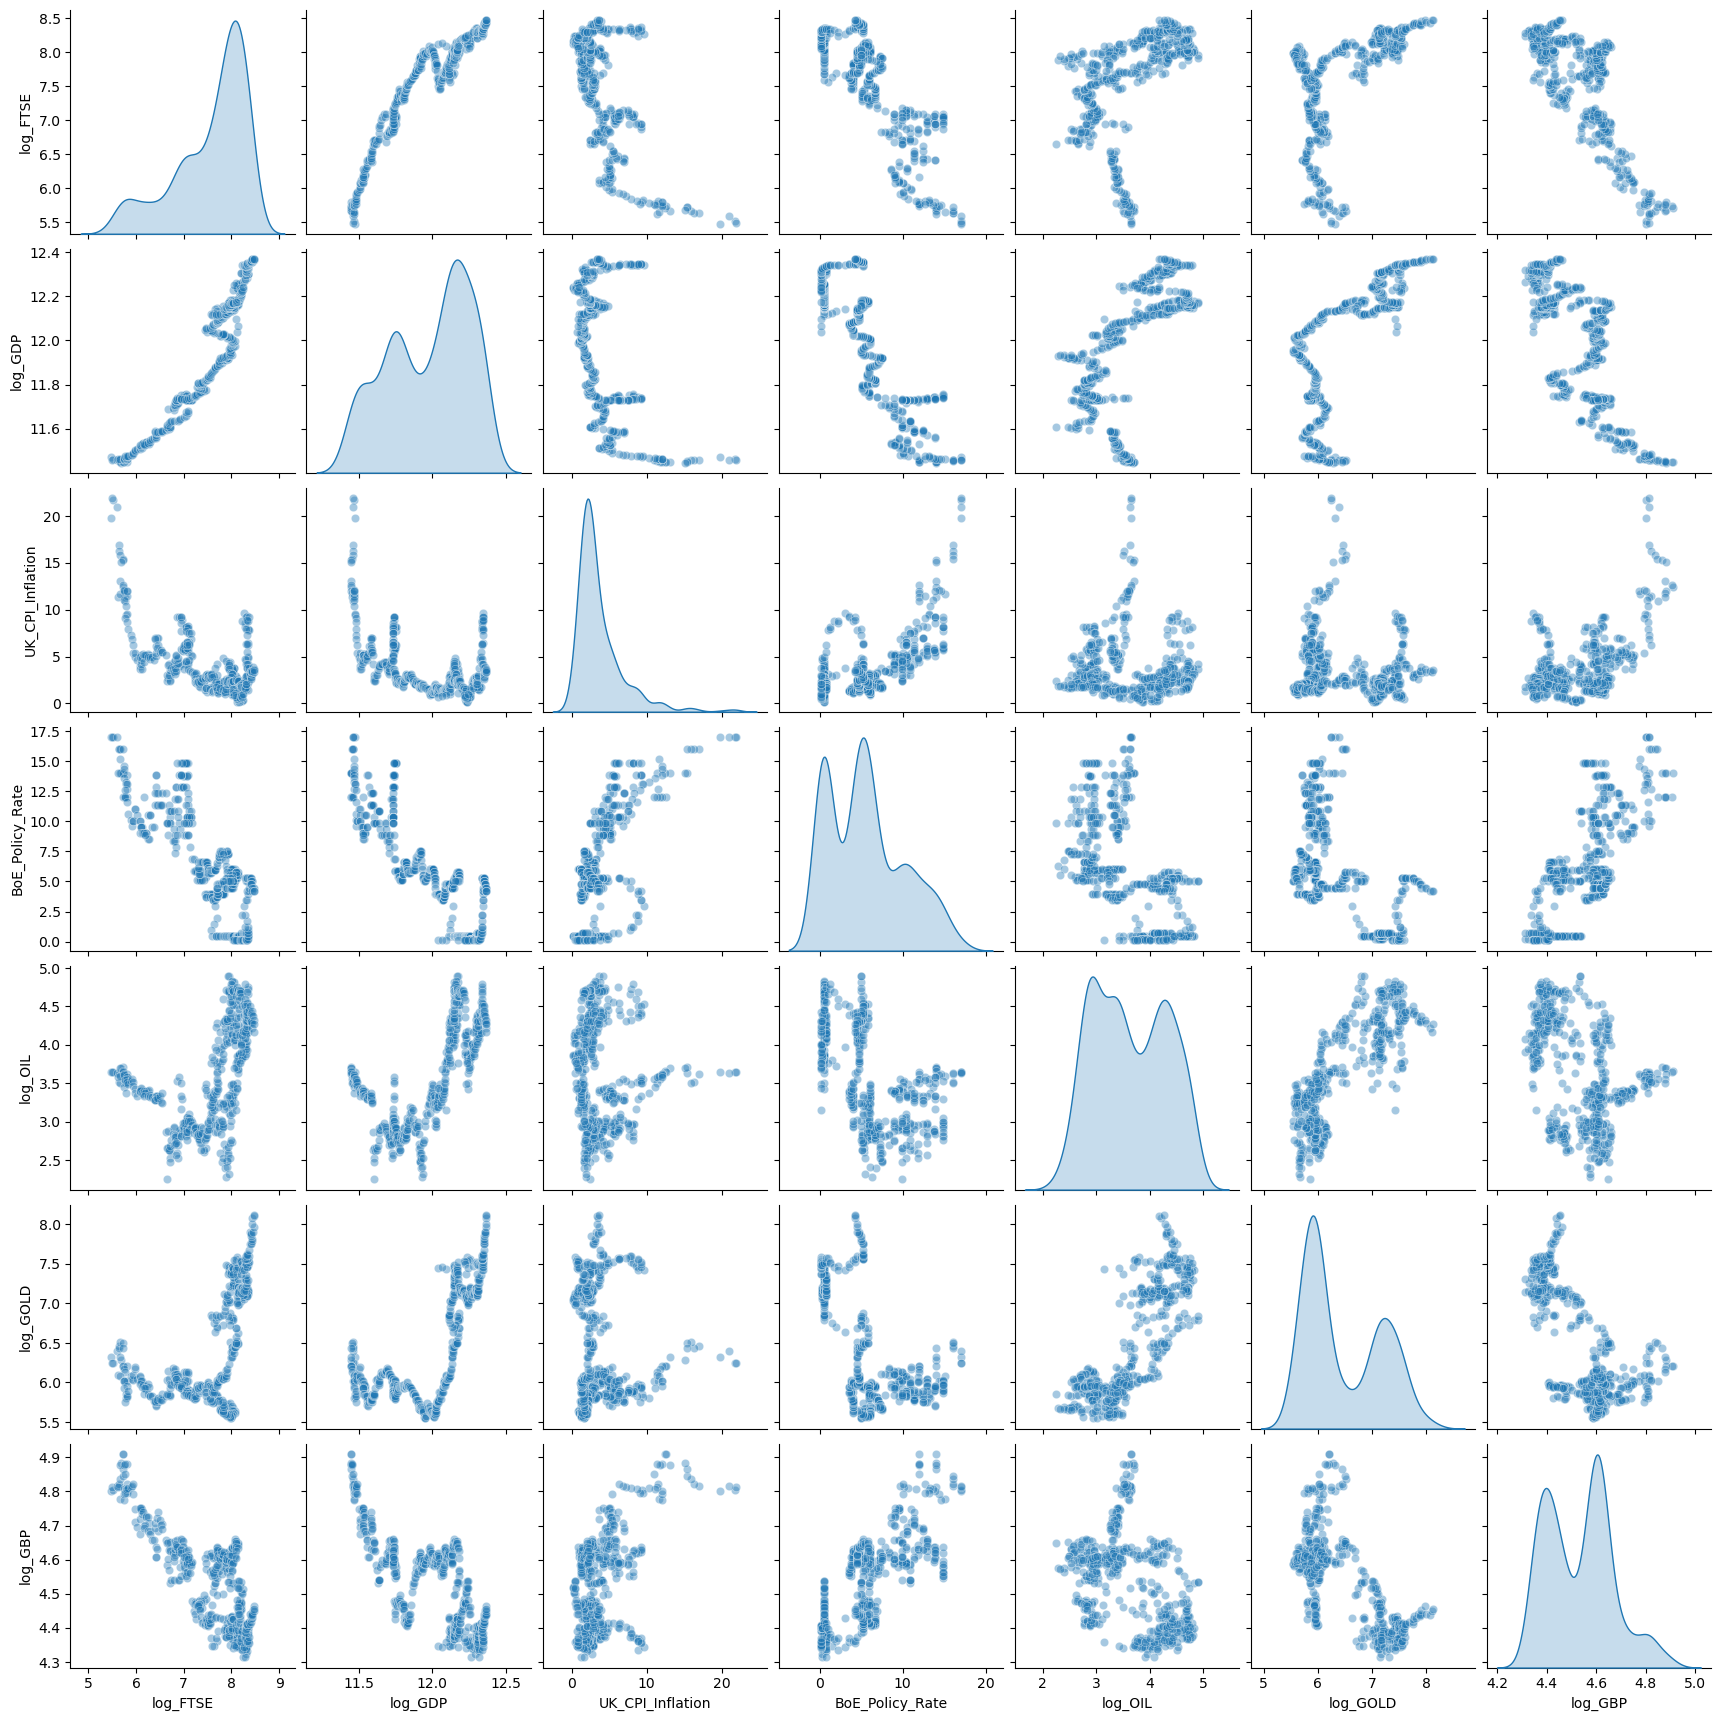

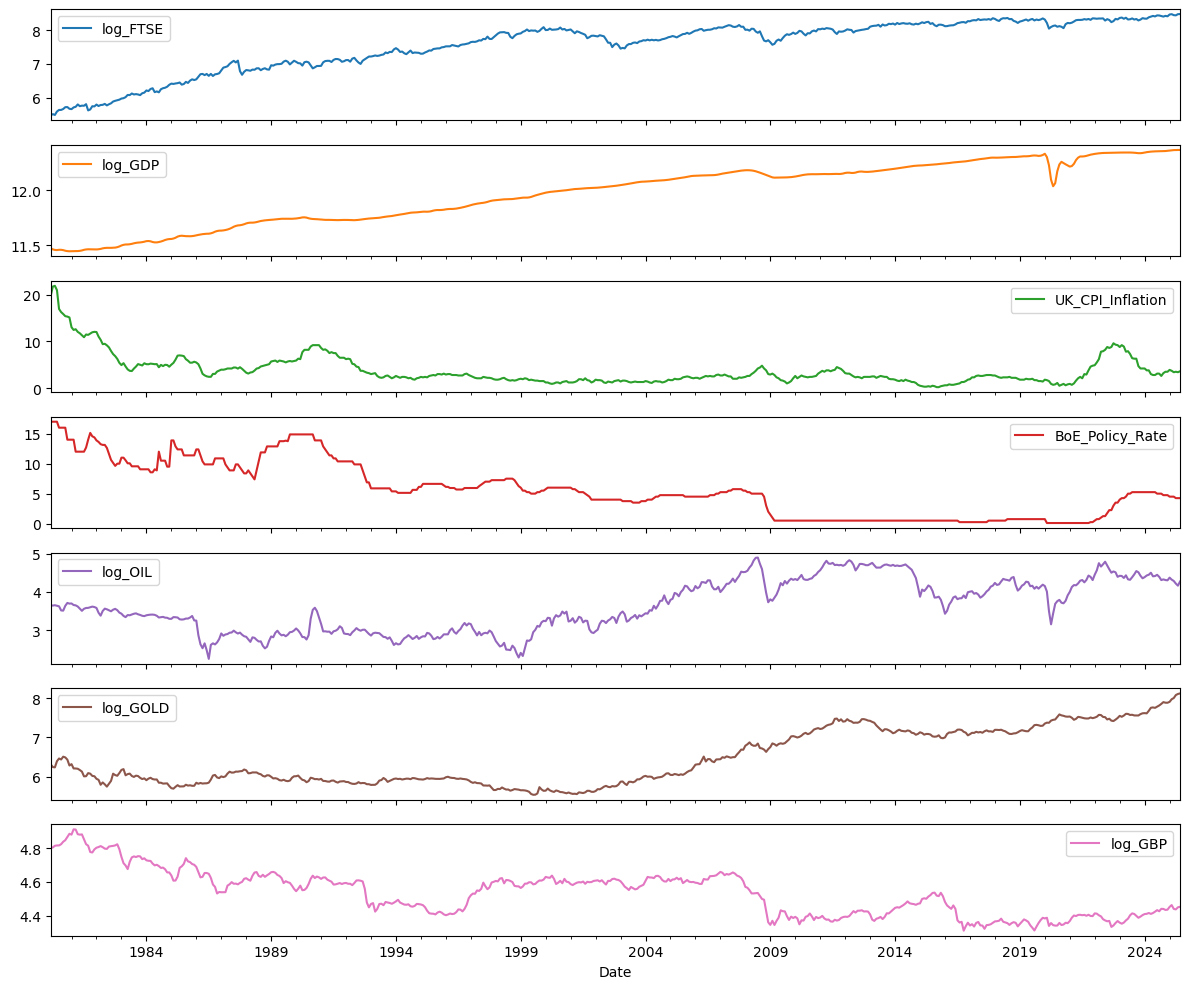

In [6]:
# Summary stats
df_model.describe()


# Pairwise correlations (log vars will be correlated)
sns.pairplot(df_model[model_vars].dropna(), diag_kind='kde', plot_kws={'alpha':0.4})
plt.show()


# Time series plot
df_model[model_vars].plot(subplots=True, figsize=(12,10))
plt.tight_layout()

### Stationarity tests (markdown + code)

Markdown: Perform ADF and KPSS for all variables. Use Phillips-Perron. For ADF use trend specification depending on visual trend (use 'ct' or 'c').

In [8]:
def adf_test(series, **kwargs):
    res = adfuller(series.dropna(), autolag='AIC', **kwargs)
    out = {'stat':res[0],'pvalue':res[1],'n_lags':res[2],'nobs':res[3]}
    return out


def kpss_test(series, **kwargs):
    stat, p, lags, crit = kpss(series.dropna(), **kwargs)
    return {'stat':stat,'pvalue':p,'n_lags':lags}


results = {}
for v in model_vars:
    s = df_model[v].dropna()
    results[v] = {
    'ADF': adf_test(s),
    'KPSS': kpss_test(s, regression='c')
    }
    if has_arch:
        pp = PhillipsPerron(s.dropna())
        results[v]['PP'] = {'stat': pp.stat, 'pvalue': pp.pvalue}


results

/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_87432/2955215124.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), **kwargs)
/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_87432/2955215124.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), **kwargs)
/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_87432/2955215124.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), **kwargs)
/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_87432/2955215124.py:8: Int

{'log_FTSE': {'ADF': {'stat': -3.094224507699914,
   'pvalue': 0.026983563674615782,
   'n_lags': 2,
   'nobs': 541},
  'KPSS': {'stat': 2.9630017781530213, 'pvalue': 0.01, 'n_lags': 15},
  'PP': {'stat': -3.1916050280748087, 'pvalue': 0.02047578473737634}},
 'log_GDP': {'ADF': {'stat': -1.8283055308834606,
   'pvalue': 0.3665020675478057,
   'n_lags': 19,
   'nobs': 524},
  'KPSS': {'stat': 3.403482154048884, 'pvalue': 0.01, 'n_lags': 15},
  'PP': {'stat': -1.2101092361256969, 'pvalue': 0.6692319253803211}},
 'UK_CPI_Inflation': {'ADF': {'stat': -4.364055688968973,
   'pvalue': 0.0003434631912689388,
   'n_lags': 19,
   'nobs': 524},
  'KPSS': {'stat': 1.1701306009567947, 'pvalue': 0.01, 'n_lags': 15},
  'PP': {'stat': -5.266242392167435, 'pvalue': 6.429742702486654e-06}},
 'BoE_Policy_Rate': {'ADF': {'stat': -2.4109704350979375,
   'pvalue': 0.1386639945291755,
   'n_lags': 6,
   'nobs': 537},
  'KPSS': {'stat': 2.857213118367273, 'pvalue': 0.01, 'n_lags': 15},
  'PP': {'stat': -2.52